<font size="6">Penetration Depth</font>

First we import some packages

In [1]:
import numpy as np
import pyPolygon as pp
from matplotlib import pyplot as plt

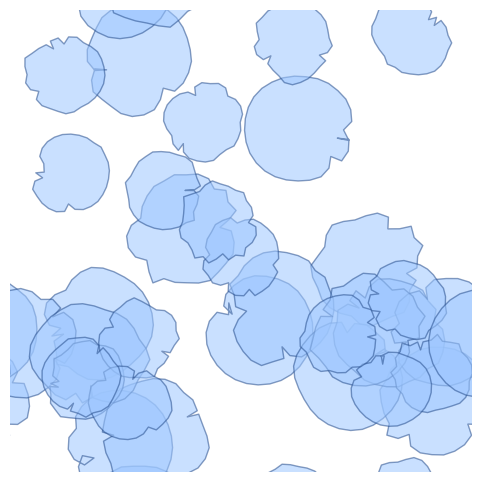

In [2]:
packing = pp.Model(N = 32, n = 32, seed = 42)
# The default if a seed isn't specified is to generate a random seed
packing.generateEquilateralPolygons(phi = 1.0, kappa = 4.0)
packing.setBiPerimeter() # first half small. second half large. default ratio 1.4
# Periodic boundary conditions are set by default, but you may try "free" boundary 
# conditions if you want to experiment:
packing.setBoundaryConditions("periodic") # The default is "periodic" so you don't need this line
packing.draw()
plt.show()

Instead of setting spring-like constraints, we instead constrain the areas and perimeters and edges. We call setConstraints. Calling this will ignore the springs on these variables as any forces would get projected out anyway.

These are the defaults:
packing.setConstraints(area = True, perimeter = False, edge = True)

In [3]:
packing.setConstraints()

Now we can proceed with finding the forces and drawing them as arrows

<Axes: >

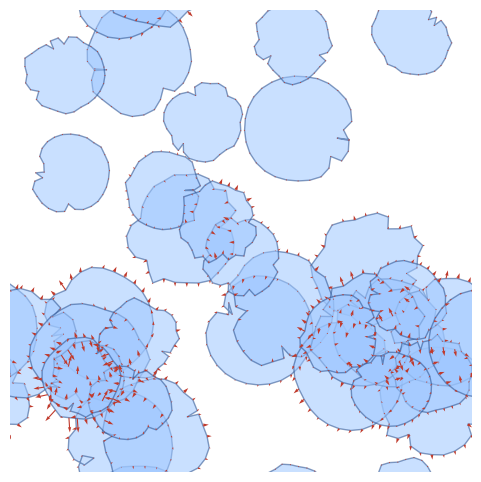

In [4]:
packing.initForceEnergy()
packing.calcForceEnergy()
forces = packing.getForces()
packing.draw(forces = forces)

Now we can try minimizing this with FIRE. Let's start with 1,000 steps and show a progress bar

FIRE (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

This was after 1000 steps.


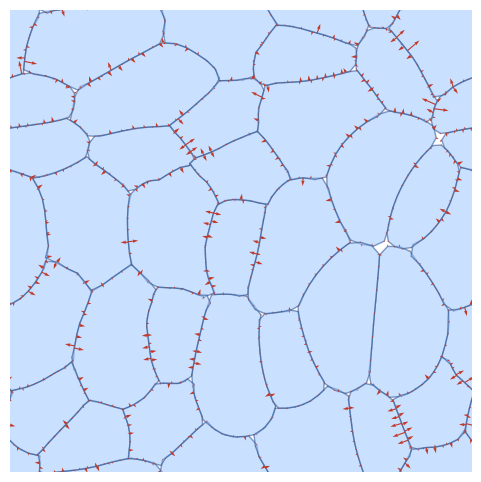

In [5]:
steps = packing.minimizeFIRE(maxSteps = 1_000, fThreshold = 1e-16, progressBar = True)
packing.draw(forces = packing.getForces())
print("This was after " + str(steps) + " steps.")

From here we can switch to the depth type

In [6]:
packing.setModelType("depth")

FIRE (constrained):   0%|          | 0/100 [00:00<?, ?it/s]

The maximum unbalanced force is 1.231967392187459e-07


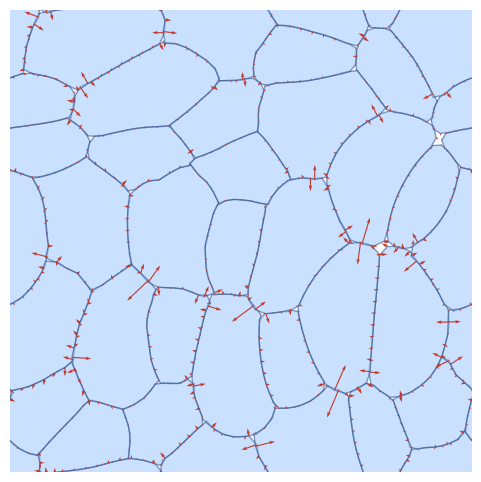

In [7]:
packing.minimizeFIRE(maxSteps = 100, fThreshold = 1e-16, progressBar = True)
packing.draw(forces = packing.getForces())
print("The maximum unbalanced force is " + str(packing.getMaxUnbalancedForce()))

CG (constrained):   0%|          | 0/100 [00:00<?, ?it/s]

The maximum unbalanced force is 9.593499116071398e-10


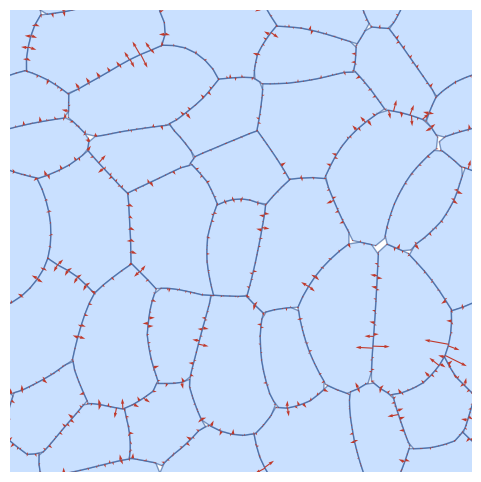

In [8]:
packing.minimizeCG(maxSteps = 100, fThreshold = 1e-16, progressBar = True)
packing.draw(forces = packing.getForces())
print("The maximum unbalanced force is " + str(packing.getMaxUnbalancedForce()))

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

The maximum unbalanced force is 6.059634416745367e-11


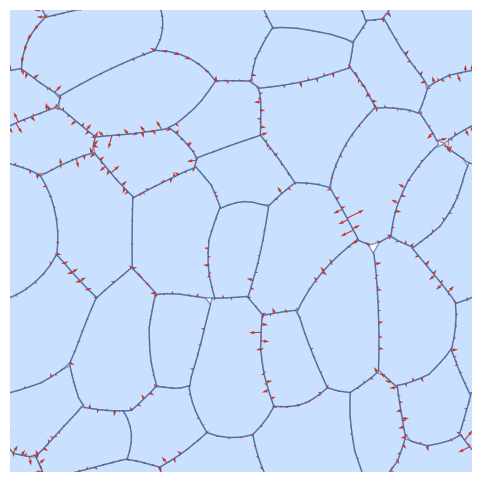

In [9]:
packing.minimizeLBFGS(maxSteps = 1_000, fThreshold = 1e-16, progressBar = True)
packing.draw(forces = packing.getForces())
print("The maximum unbalanced force is " + str(packing.getMaxUnbalancedForce()))

CG (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

The maximum unbalanced force is 1.3476375120282324e-11


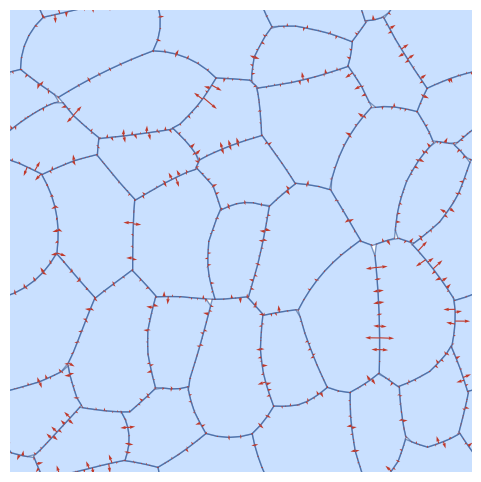

In [10]:
packing.minimizeCG(maxSteps = 1_000, fThreshold = 1e-16, progressBar = True)
packing.draw(forces = packing.getForces())
print("The maximum unbalanced force is " + str(packing.getMaxUnbalancedForce()))